In [29]:
import os
import re
import json
import subprocess
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
import faiss
import matplotlib.pyplot as plt
import seaborn as sns
import torch

In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [31]:
def preprocess(s):
    if not isinstance(s, str):
        return ""
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"http\S+|www\.\S+", "<URL>", s)
    s = re.sub(r"\S+@\S+", "<EMAIL>", s)
    s = re.sub(r"<[^>]+>", " ", s)
    s = ''.join(ch for ch in s if ord(ch) >= 32)
    s = re.sub(r"['\"]", "", s)
    return s.strip()

In [32]:
BASE_DIR = Path.cwd()
IR_DIR = BASE_DIR / "IR2025"
EMBED_DIR = BASE_DIR / "Embeddings"
EMBED_DIR.mkdir(exist_ok=True)
IR_DIR.mkdir(exist_ok=True)

DOCS_CSV = IR_DIR / "documents.csv"
QUERIES_CSV = IR_DIR / "queries.csv"
DOC_EMBED_FILE = EMBED_DIR / "ir2025_embeddings.npy"
QUERY_EMBED_FILE = EMBED_DIR / "query_embeddings.npy"

QRELS_CSV = IR_DIR / "qrels.csv"       # source csv (if exists)
QRELS_TXT = IR_DIR / "qrels.txt"      # will be created inside IR2025
TREC_EVAL_BIN = IR_DIR / "trec_eval" / "trec_eval.exe"  # adjust if needed


In [33]:
# hyperparams
DOC_BATCH = 64
QUERY_BATCH = 32
FAISS_USE_COSINE = True
PRF_ENABLED = True              # αν θέλεις PRF ενεργό
PRF_TOP_M = 5                   # top-m docs for feedback
PRF_ALPHA = 0.7                 # weight for original query
PRF_BETA = 0.3                  # weight for feedback mean
REQUERY_CANDIDATES = 200        # initial candidate size if using candidate-limited PRF (not required)
RESULT_KS = (20, 30, 50)


In [34]:
if not DOCS_CSV.exists():
    raise SystemExit(f"documents.csv not found: {DOCS_CSV}")
if not QUERIES_CSV.exists():
    raise SystemExit(f"queries.csv not found: {QUERIES_CSV}")

df_docs = pd.read_csv(DOCS_CSV)
df_queries = pd.read_csv(QUERIES_CSV)

# Ensure columns: try to detect ID and Text column names
def detect_id_text_columns(df):
    cols = list(df.columns)
    id_col = None
    text_col = None
    # heuristics
    for c in cols:
        if c.lower() in ("id", "docid", "doc_id", "docId"):
            id_col = c
        if c.lower() in ("text", "content", "body", "document"):
            text_col = c
    # fallback
    if id_col is None:
        id_col = cols[0]
    if text_col is None:
        # try second column
        if len(cols) > 1:
            text_col = cols[1]
        else:
            text_col = cols[0]
    return id_col, text_col

DOC_ID_COL, DOC_TEXT_COL = detect_id_text_columns(df_docs)
QID_COL, QTEXT_COL = detect_id_text_columns(df_queries)

# Apply preprocess and ensure ID are strings
df_docs = df_docs.dropna(subset=[DOC_TEXT_COL]).copy()
df_docs[DOC_TEXT_COL] = df_docs[DOC_TEXT_COL].astype(str).map(preprocess)
df_docs[DOC_ID_COL] = df_docs[DOC_ID_COL].astype(str).str.strip()

df_queries = df_queries.dropna(subset=[QTEXT_COL]).copy()
df_queries[QTEXT_COL] = df_queries[QTEXT_COL].astype(str).map(preprocess)
df_queries[QID_COL] = df_queries[QID_COL].astype(str).str.strip()

print(f"Loaded {len(df_docs)} documents; {len(df_queries)} queries.")
print(f"Using document ID column: {DOC_ID_COL}, text column: {DOC_TEXT_COL}")
print(f"Using query ID column: {QID_COL}, text column: {QTEXT_COL}")


Loaded 18316 documents; 10 queries.
Using document ID column: ID, text column: Text
Using query ID column: ID, text column: Text


In [35]:
model = SentenceTransformer("all-mpnet-base-v2",device=device)

In [36]:
def load_or_create_embeddings():
    if DOC_EMBED_FILE.exists() and QUERY_EMBED_FILE.exists():
        print("Loading cached embeddings...")
        doc_emb = np.load(DOC_EMBED_FILE)
        query_emb = np.load(QUERY_EMBED_FILE)
        print(f"Loaded doc embeddings shape: {doc_emb.shape}")
        print(f"Loaded query embeddings shape: {query_emb.shape}")
        return doc_emb, query_emb

    # ---- CREATE DOCUMENT EMBEDDINGS ----
    print("Generating document embeddings on GPU...")
    doc_texts = df_docs[DOC_TEXT_COL].tolist()
    doc_emb = model.encode(
        doc_texts,
        batch_size=DOC_BATCH,
        device=device,                     
        convert_to_numpy=True,
        show_progress_bar=True
    )
    np.save(DOC_EMBED_FILE, doc_emb)
    print(f"Saved doc embeddings → {DOC_EMBED_FILE}")

    # ---- CREATE QUERY EMBEDDINGS ----
    print("Generating query embeddings on GPU...")
    query_texts = df_queries[QTEXT_COL].tolist()
    query_emb = model.encode(
        query_texts,
        batch_size=QUERY_BATCH,
        device=device,                    
        convert_to_numpy=True,
        show_progress_bar=True
    )
    np.save(QUERY_EMBED_FILE, query_emb)
    print(f"Saved query embeddings → {QUERY_EMBED_FILE}")

    return doc_emb, query_emb


doc_embeddings, query_embeddings = load_or_create_embeddings()


Generating document embeddings on GPU...


Batches: 100%|██████████| 287/287 [35:12<00:00,  7.36s/it] 


Saved doc embeddings → c:\Users\swkra\OneDrive - aueb.gr\Uni\7th-semester\SystemsRetr\ergasia\Embeddings\ir2025_embeddings.npy
Generating query embeddings on GPU...


Batches: 100%|██████████| 1/1 [00:00<00:00,  1.72it/s]

Saved query embeddings → c:\Users\swkra\OneDrive - aueb.gr\Uni\7th-semester\SystemsRetr\ergasia\Embeddings\query_embeddings.npy


In [44]:
def build_faiss_index(embeddings, use_cosine=True, save_path: Path = None):
    if save_path and save_path.exists():
        try:
            save_path.unlink()
            print(f"Old index deleted: {save_path}")
        except:
            print("Failed to delete old index")

    emb = embeddings.astype("float32")
    faiss.normalize_L2(emb)

    dim = emb.shape[1]

    if use_cosine:
        metric = faiss.METRIC_INNER_PRODUCT
    else:
        metric = faiss.METRIC_L2

    cpu_index = faiss.IndexHNSWFlat(dim, 32, metric)
    cpu_index.hnsw.efConstruction = 128
    cpu_index.hnsw.efSearch = 128

    index = cpu_index
    print("Using CPU for FAISS index (GPU not available in this FAISS install)")

    index.add(emb)
    print(f"Built FAISS index: {index.ntotal} vectors, dim={dim}")

    if save_path:
        faiss.write_index(cpu_index, str(save_path))
        print(f"Saved FAISS index to {save_path}")

    return index


index = build_faiss_index(doc_embeddings, use_cosine=True)


Using CPU for FAISS index (GPU not available in this FAISS install)


Built FAISS index: 18316 vectors, dim=768


In [45]:
def expand_query_with_prf(q_emb, index, top_m=PRF_TOP_M, alpha=PRF_ALPHA, beta=PRF_BETA, candidate_pool=REQUERY_CANDIDATES):
    """
    Perform PRF by averaging top_m doc embeddings from an initial candidate search.
    Returns expanded query embedding (same shape).
    """
    q = q_emb.reshape(1, -1).astype("float32")
    if FAISS_USE_COSINE:
        faiss.normalize_L2(q)

    # initial candidate retrieval (candidate_pool)
    D, I = index.search(q, candidate_pool)
    top_idxs = I[0][:top_m]
    if len(top_idxs) == 0:
        return q_emb

    top_embs = doc_embeddings[top_idxs].astype("float32")
    if FAISS_USE_COSINE:
        faiss.normalize_L2(top_embs)

    feedback_mean = np.mean(top_embs, axis=0)
    # combine and renormalize
    expanded = alpha * q_emb + beta * feedback_mean
    if FAISS_USE_COSINE:
        expanded = expanded / (np.linalg.norm(expanded) + 1e-12)
    return expanded


In [46]:
def generate_faiss_results(df_docs, df_queries, query_embeddings, index, ks=(20,30,50), prf_enabled=PRF_ENABLED):
    faiss.normalize_L2(query_embeddings)
    for k in ks:
        out_file = IR_DIR / f"results_faiss_{k}.txt"
        print(f"Writing results to {out_file}")
        with open(out_file, "w", encoding="utf-8") as outf:
            for q_idx, row in df_queries.iterrows():
                qid = str(row[QID_COL])
                q_emb = query_embeddings[q_idx].astype("float32")
                if prf_enabled:
                    # compute expanded query
                    expanded_q = expand_query_with_prf(q_emb, index, top_m=PRF_TOP_M, alpha=PRF_ALPHA, beta=PRF_BETA)
                    q_vec = expanded_q.reshape(1, -1).astype("float32")
                    if FAISS_USE_COSINE:
                        faiss.normalize_L2(q_vec)
                    D, I = index.search(q_vec, max( max(ks), 50 ))  # retrieve enough to fill k
                else:
                    q_vec = q_emb.reshape(1, -1).astype("float32")
                    D, I = index.search(q_vec, max(ks))

                # write top-k results (only up to requested k)
                for rank, (doc_idx, score) in enumerate(zip(I[0][:k], D[0][:k]), start=1):
                    docid = str(df_docs.iloc[doc_idx][DOC_ID_COL])
                    outf.write(f"{qid} Q0 {docid} {rank} {float(score):.6f} FAISS\n")
        print(f"Created {out_file.name}")

# run generation
generate_faiss_results(df_docs, df_queries, query_embeddings, index, ks=RESULT_KS, prf_enabled=PRF_ENABLED)


Writing results to c:\Users\swkra\OneDrive - aueb.gr\Uni\7th-semester\SystemsRetr\ergasia\IR2025\results_faiss_20.txt
Created results_faiss_20.txt
Writing results to c:\Users\swkra\OneDrive - aueb.gr\Uni\7th-semester\SystemsRetr\ergasia\IR2025\results_faiss_30.txt
Created results_faiss_30.txt
Writing results to c:\Users\swkra\OneDrive - aueb.gr\Uni\7th-semester\SystemsRetr\ergasia\IR2025\results_faiss_50.txt
Created results_faiss_50.txt


In [47]:
class Evaluation:
    def _rel(self, p: Path):
        try:
            rel = p.resolve().relative_to(self.data_dir.resolve())
        except Exception:
            rel = Path(p.name)
        return str(rel).replace("\\", "/")

    def __init__(self, search_client, data_dir, qrels_csv_path, qrels_txt_path, trec_eval_bin):
        self.search = search_client
        self.data_dir = Path(data_dir)
        self.qrels_csv_path = Path(qrels_csv_path)
        self.qrels_txt_path = Path(qrels_txt_path) if qrels_txt_path else self.data_dir/ "IR2025" / "qrels.txt"

        self._ensure_trec_qrels()

        if trec_eval_bin is None:
            self.trec_eval_bin = self._find_trec_eval()
        else:
            self.trec_eval_bin = Path(trec_eval_bin)

        if not self.trec_eval_bin or not self.trec_eval_bin.exists():
            raise SystemExit("trec_eval binary not found. Put trec_eval.exe στον φάκελο trec_eval ή δώσε σωστό path στον constructor.")

        if not self.qrels_txt_path.exists():
            raise SystemExit(f"qrels file not found: {self.qrels_txt_path}")

        print(f"Using trec_eval at: {self._rel(self.trec_eval_bin)}")
        print(f"Using qrels file: {self._rel(self.qrels_txt_path)}")

    def _fix_and_write_qrels(self):
        if not self.qrels_csv_path.exists():
            raise SystemExit(f"qrels.csv not found: {self.qrels_csv_path}")

        dfq = pd.read_csv(self.qrels_csv_path, sep=None, engine="python", encoding="utf-8-sig",)
        dfq = dfq.dropna(how="all")
        dfq = dfq.astype(str).applymap(lambda x: x.strip())
        cols = list(dfq.columns)

        # optional: docids from one sample results file
        res_docids = set()
        sample_results_path = self.data_dir / "IR2025" / "results_faiss_20.txt"
        if sample_results_path.exists():
            with open(sample_results_path, encoding="utf-8", errors="replace") as f:
                for ln in f:
                    parts = re.split(r"\s+", ln.strip())
                    if len(parts) >= 3:
                        res_docids.add(parts[2])

        candidates = []
        for c in cols:
            vals = dfq[c].dropna().astype(str).str.strip().unique()[:200].tolist()
            inter = len(set(vals) & res_docids) if res_docids else 0
            num_like = sum(1 for v in vals if re.match(r"^\d+$", v))
            candidates.append((c, inter, num_like, vals[:5]))

        docid_col = max(candidates, key=lambda x: (x[1], x[2]))[0]
        qid_col = cols[0]
        rel_col = None
        for c, inter, num_like, vals in candidates:
            if c in (qid_col, docid_col):
                continue
            sample_vals = dfq[c].dropna().astype(str).str.strip().unique()[:50].tolist()
            if sample_vals and all(re.match(r"^\d+$", v) for v in sample_vals):
                rel_col = c
                break
        if rel_col is None:
            others = [c for c in cols if c not in (qid_col, docid_col)]
            rel_col = others[-1] if others else cols[-1]

        with open(self.qrels_txt_path, "w", encoding="utf-8") as out:
            for _, row in dfq.iterrows():
                qid = str(row[qid_col]).strip()
                docid = str(row[docid_col]).strip()
                rel = str(row[rel_col]).strip()
                if not qid or not docid or docid.upper() == "Q0":
                    continue
                out.write(f"{qid} 0 {docid} {rel}\n")

        print(f"Wrote TREC qrels -> {self._rel(self.qrels_txt_path)} (qid_col={qid_col}, docid_col={docid_col}, rel_col={rel_col})")

    def _ensure_trec_qrels(self):
        if self.qrels_txt_path.exists():
            print(f"Using existing TREC qrels: {self._rel(self.qrels_txt_path)}")
            return
        print("TREC qrels not found, creating from qrels.csv ...")
        self._fix_and_write_qrels()

    def _find_trec_eval(self):
        candidates = [
            self.data_dir / "trec_eval" / "trec_eval.exe",
            self.data_dir / "trec_eval" / "trec_eval",
            self.data_dir / "trec_eval.exe",
            self.data_dir / "trec_eval",
        ]
        for p in candidates:
            if p.exists():
                return p

        p_on_path = shutil.which("trec_eval") or shutil.which("trec_eval.exe")
        if p_on_path:
            return Path(p_on_path)

        if self.data_dir.exists():
            for p in self.data_dir.rglob("trec_eval*"):
                if p.is_file():
                    return p
        return None

    def _run_trec_eval_for_file(self, results_file: Path):
        if not results_file.exists():
            raise SystemExit(f"results file not found: {results_file}")

        cmd = (
            f"{self._rel(self.trec_eval_bin)} "
            f"{self._rel(self.qrels_txt_path)} "
            f"{self._rel(results_file)} -m all_trec"
        )
        print("Running:", cmd)
        proc = subprocess.run(cmd, capture_output=True, text=True)

        if proc.returncode != 0:
            print("--- trec_eval stderr ---")
            print(proc.stderr)
            raise SystemExit(f"trec_eval failed for {results_file} (rc={proc.returncode})")

        parsed = {}
        for line in proc.stdout.strip().splitlines():
            parts = re.split(r"\s+", line.strip())
            if len(parts) < 3:
                continue

            metric = parts[0]
            target = parts[1]
            value_str = parts[-1]

            if target.lower() != "all":
                continue

            if metric.lower() == "map":
                try:
                    parsed["MAP"] = float(value_str)
                except ValueError:
                    pass
                continue

            m = re.match(r"^P_(\d+)$", metric)
            if m:
                k = int(m.group(1))
                key = f"P@{k}"
                try:
                    parsed[key] = float(value_str)
                except ValueError:
                    pass
                continue

        return {
            "P@5":  parsed.get("P@5"),
            "P@10": parsed.get("P@10"),
            "P@15": parsed.get("P@15"),
            "P@20": parsed.get("P@20"),
            "MAP":  parsed.get("MAP"),
        }

    def evaluate_with_trec_eval(self, ks=(20, 30, 50), out_summary_path: Path = None):
        summary_rows = []

        for k in ks:
            results_file = self.data_dir/ "IR2025"/ f"results_faiss_{k}.txt"
            metrics = self._run_trec_eval_for_file(results_file)
            row = {"retrieval_k": k}
            row.update(metrics)
            summary_rows.append(row)

        df_trec = (
            pd.DataFrame(summary_rows)
            .sort_values("retrieval_k")
            .reset_index(drop=True)
        )

        print("TREC Evaluation Summary:")
        print(df_trec)

        if out_summary_path is not None:
            with open(out_summary_path, "w", encoding="utf-8") as f:
                for _, r in df_trec.iterrows():
                    k = int(r["retrieval_k"])
                    for kk in [5, 10, 15, 20]:
                        val = r.get(f"P@{kk}")
                        f.write(f"P_{kk}\tall\t{val:.4f}\n")
                    f.write(f"map\tall\t{r['MAP']:.4f}\n\n")

        return df_trec

In [48]:
evaluator = Evaluation(
    search_client=None,
    data_dir=BASE_DIR,
    qrels_csv_path=QRELS_CSV,
    qrels_txt_path=QRELS_TXT,
    trec_eval_bin=TREC_EVAL_BIN
)

df_faiss = evaluator.evaluate_with_trec_eval(ks=RESULT_KS, out_summary_path=BASE_DIR / "trec_eval_faiss_summary.txt")

Using existing TREC qrels: IR2025/qrels.txt
Using trec_eval at: IR2025/trec_eval/trec_eval.exe
Using qrels file: IR2025/qrels.txt
Running: IR2025/trec_eval/trec_eval.exe IR2025/qrels.txt IR2025/results_faiss_20.txt -m all_trec
Running: IR2025/trec_eval/trec_eval.exe IR2025/qrels.txt IR2025/results_faiss_30.txt -m all_trec
Running: IR2025/trec_eval/trec_eval.exe IR2025/qrels.txt IR2025/results_faiss_50.txt -m all_trec
TREC Evaluation Summary:
   retrieval_k  P@5  P@10  P@15  P@20     MAP
0           20  0.6  0.48   0.4  0.36  0.3107
1           30  0.6  0.48   0.4  0.36  0.3546
2           50  0.6  0.48   0.4  0.36  0.3800


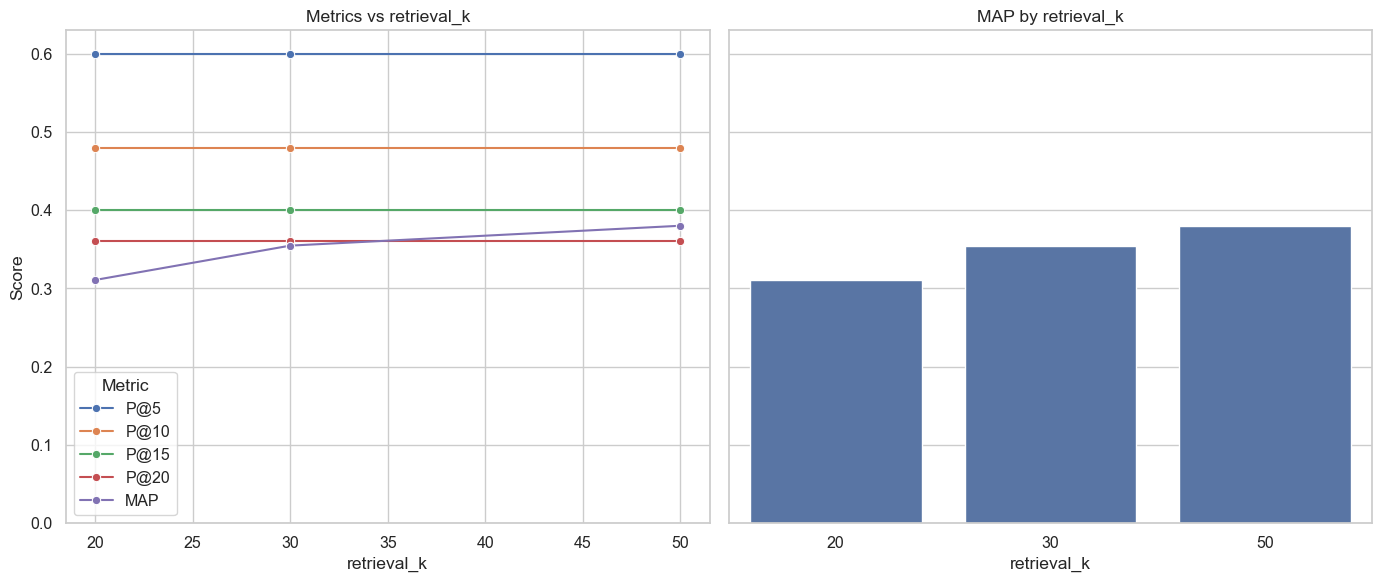

In [49]:
def visualize_metrics(df):
    metrics = ["P@5", "P@10", "P@15", "P@20", "MAP"]
    df_melt = df.melt(id_vars="retrieval_k", value_vars=metrics, var_name="Metric", value_name="Score")

    sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    sns.lineplot(data=df_melt, x="retrieval_k", y="Score", hue="Metric", marker="o", ax=ax1)
    ax1.set_title("Metrics vs retrieval_k")
    ax1.set_xlabel("retrieval_k")
    ax1.set_ylabel("Score")

    map_only = df_melt[df_melt["Metric"] == "MAP"]
    sns.barplot(data=map_only, x="retrieval_k", y="Score", ax=ax2)
    ax2.set_title("MAP by retrieval_k")

    plt.tight_layout()
    plt.show()

visualize_metrics(df_faiss)